# Image Compression using Modulo-Compressive Sensing

## Importing Libraries and Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optimization.milp import solve_modulo_cs_milp
from optimization.moram import MultiScaleMoRAM
from optimization.msjp import MultiScaleJusticePursuit

from utils.generate_data import generate_CS_matrix, generate_measurements
from utils.sample_images import sample_mnist

## Data Loading

In [2]:
# load csv data to a numpy array
# train_data = np.loadtxt('data/mnist_train.csv', delimiter=',')
test_data = np.loadtxt('data/mnist_test.csv', delimiter=',')

## Testing Sparse Image Recovery

### Selecting the image at random

In [45]:
image_idx = np.floor(np.random.rand()*10000).astype('int')
image = test_data[image_idx,1:]
image_idx

np.int64(9831)

In [46]:
A = generate_CS_matrix(M=300)
y = generate_measurements(image_data=image, A=A)
z = A @ image

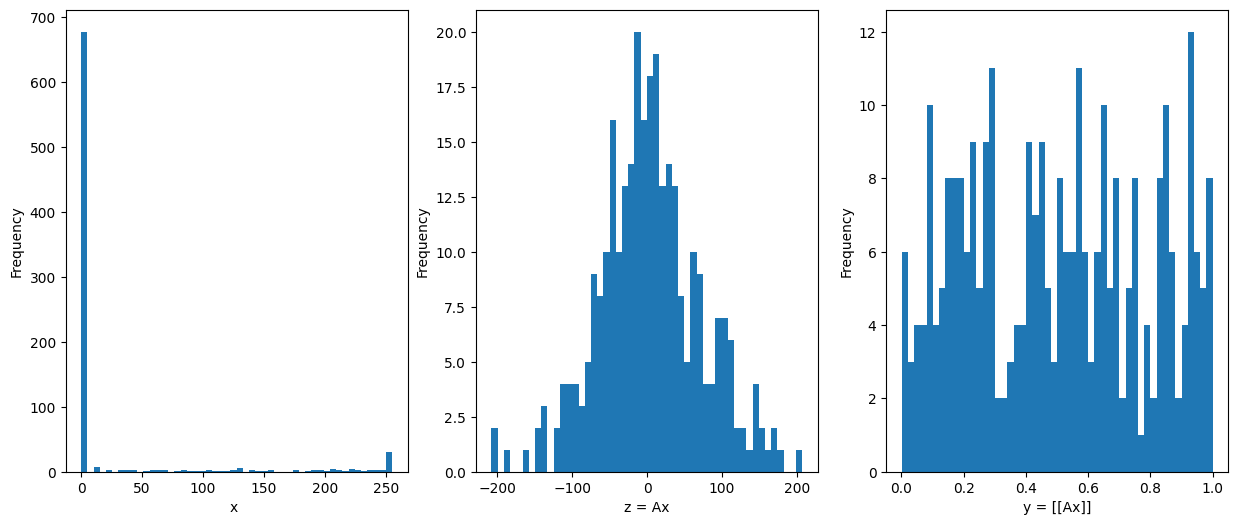

In [47]:
# plotting the distribution of measurements
plt.figure(figsize=(15, 6))

plt.subplot(1,3,1)
plt.hist(image, bins=50)
plt.xlabel('x ')
plt.ylabel('Frequency')

plt.subplot(1,3,2)
plt.hist(z, bins=50)
plt.xlabel('z = Ax')
plt.ylabel('Frequency')

plt.subplot(1,3,3)
plt.hist(y, bins=50)
plt.xlabel('y = [[Ax]]')
plt.ylabel('Frequency')

plt.tight_layout
plt.show()

### Multi-Scale Justice Pursuit

In [48]:
alpha_list = [2**l/512 for l in range(10)]
y_scaled = np.array([generate_measurements(image, A, scale=alpha) for alpha in alpha_list])

In [59]:
def get_sparsity_diff(img_est, img):
    estimated_sparsity = (img_est>0.5).sum()
    actual_sparsity = (img>0.5).sum()

    return estimated_sparsity, abs(actual_sparsity-estimated_sparsity)

def get_normalized_mse(img_est, img):
    norm_mse = np.linalg.norm(img-img_est)**2 / np.linalg.norm(image)**2
    return norm_mse

In [50]:
msjp_inst = MultiScaleJusticePursuit(
    y = y_scaled,
    scales=alpha_list,
    A = A,
    print_debug_errors=False
)

#### Tuning Penalty parameters

In [2]:
lam_x_options = [1e-4, 1e-3, 5e-3, 1e-2]
lam_e_options = [1e-3, 5e-3, 1e-2, 5e-2]
lam_options = list(zip(lam_x_options, lam_e_options))

nmse_list = []
for (lam_x, lam_e) in lam_options:

        fista_config={
            'niter': 500,
            'lam_x': lam_x,
            'lam_e': lam_e,
            'tol': 1e-5
        }
        
        img_est = msjp_inst.recover_signal(jp_iters=100, fista_config=fista_config)
        # getting metrics
        norm_mse = get_normalized_mse(img_est=img_est, img=image)
        print(f"Normalized Reconstruction MSE for (\lambda_x, \lambda_e) = {(lam_x, lam_e)} = {norm_mse:.3f}")
        nmse_list.append(norm_mse)

best_config = lam_options[np.argmin(np.array(nmse_list))]
print(f"Best config: (\lambda_x, \lambda_e) = {best_config}")

NameError: name 'msjp_inst' is not defined

In [ ]:
msjp_inst.print_debug_errors = True

img_est = msjp_inst.recover_signal(
    jp_iters=100,
    fista_config={
        'niter': 500,
        'lam_x': best_config[0],
        'lam_e': best_config[1],
        'tol': 1e-5
    }
) 

RUNNING FISTA-BACKED JUSTICE PURSUIT FOR 1.0 FOLDS...
Centered modulo working correctly: True
FOR 1.0 FOLDS, (relative) l2-norm error in measurements = 0.014917
RUNNING FISTA-BACKED JUSTICE PURSUIT FOR 2.0 FOLDS...
||x||_1: 21343.56978326153
||e||_1: 0.0
number |e_i| > 0.25: 0
fit residual: 1.1903742267771313
Mean unclipped fold update = 0.0
300/300 pixels are in agreement in with the error in fold-update
300/300 proposed fold updates were adjacent to each other
FOR 2.0 FOLDS, (relative) l2-norm error in measurements = 0.015071
RUNNING FISTA-BACKED JUSTICE PURSUIT FOR 4.0 FOLDS...
||x||_1: 21343.511218825424
||e||_1: 0.0
number |e_i| > 0.25: 0
fit residual: 2.143100297638563
Mean unclipped fold update = 0.0
300/300 pixels are in agreement in with the error in fold-update
300/300 proposed fold updates were adjacent to each other
FOR 4.0 FOLDS, (relative) l2-norm error in measurements = 0.015380
RUNNING FISTA-BACKED JUSTICE PURSUIT FOR 8.0 FOLDS...
||x||_1: 21343.394490155144
||e||_1: 0.

#### Results

In [57]:
est_sparsity, sparsity_diff = get_sparsity_diff(img_est=img_est, img=image)
print(f"Estimated Sparsity = {est_sparsity}; |Sparsity Error| = {sparsity_diff}")

norm_mse = get_normalized_mse(img_est, image)
print(f"Normalized Reconstruction MSE = {norm_mse:.4f}")

Estimated Sparsity = 196; |Sparsity Error| = 88
Normalized Reconstruction MSE = 0.3280


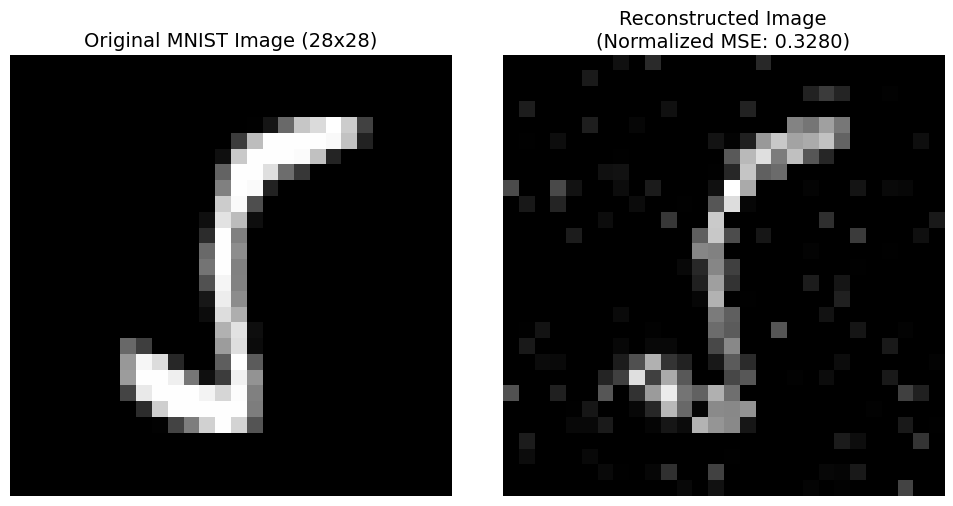

In [53]:
# reshaping the arrrays
reconstructed_scaled = np.clip(img_est, 0.0, 255.0)
img_reconstructed = reconstructed_scaled.reshape(28, 28)

# 4. Plot the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original Image Plot (Using the 14x14 downsampled image 'img_small')
axes[0].imshow(image.reshape(28,28), cmap='gray')
axes[0].set_title("Original MNIST Image (28x28)", fontsize=14)
axes[0].axis('off')

# Reconstructed Image Plot
axes[1].imshow(img_reconstructed, cmap='gray')
axes[1].set_title(f"Reconstructed Image\n(Normalized MSE: {norm_mse:.4f})", fontsize=14)
axes[1].axis('off')

plt.tight_layout()

# plt.savefig("reconstruction14x14_1.png", dpi=300)
plt.show()

## MSJP Sparse Recovery Pipeline

### Tuning the JP Penalty Parameters over the training set

In [2]:
def get_sparsity_diff(img_est, img):
    estimated_sparsity = (img_est>0.5).sum()
    actual_sparsity = (img>0.5).sum()

    return estimated_sparsity, abs(actual_sparsity-estimated_sparsity)

def get_normalized_mse(img_est, img):
    norm_mse = np.linalg.norm(img-img_est)**2 / np.linalg.norm(img)**2
    return norm_mse

In [9]:
def tune_penalty_parameters(img_set: np.ndarray, m:int, scales:list):

    print(f"============= TUNING PARMETERS FOR {m} MEASUREMENTS ====================")
    # lam_x_options = [1e-4, 1e-3, 5e-3, 1e-2]
    # lam_e_options = [1e-3, 5e-3, 1e-2, 5e-2]
    lam_options = [
        (1e-4, 1e-3), (1e-4, 5e-3), (1e-3, 5e-3), (1e-3, 1e-2), (5e-3, 1e-2), (5e-3, 5e-2)
    ]

    train_nmse_list = []    # storing the mean reconstruction NMSEs over the training set for each configuration 

    for (lam_x, lam_e) in lam_options:

        nmse_list = []

        for i in range(img_set.shape[0]):
            img=img_set[i,:]            
            # generate CS matrix of m measurements at random
            A = generate_CS_matrix(M=m)
            # scaled dense acquisitions
            y = np.array([generate_measurements(img, A, scale=alpha) for alpha in scales])

            # initialize MSJP
            msjp_inst = MultiScaleJusticePursuit(
                y = y,
                scales=alpha_list,
                A = A,
                print_debug_errors=False
            )
            # run MSJP reconstruction
            img_est = msjp_inst.recover_signal(jp_iters=100, fista_config={
                'niter': 500,
                'lam_x': lam_x,
                'lam_e': lam_e,
                'tol': 1e-5
            })

            # getting the NMSE
            norm_mse = get_normalized_mse(img_est, img); nmse_list.append(norm_mse)

        print(f"{len(img_set)} images reconstructed with (\lambda_x, \lambda_e) = {(lam_x, lam_e)}")
        train_nmse_list.append(np.array(nmse_list).mean())

    best_config = lam_options[np.argmin(np.array(train_nmse_list))]
    return best_config

In [ ]:
import json

train_set = sample_mnist(N=20, split='train')
alpha_list = [2**l/512 for l in range(10)]

train_config_dict = {
    m: tune_penalty_parameters(train_set, m, alpha_list) 
    for m in range(100,401,50)
}

============= TUNING PARMETERS FOR 100 MEASUREMENTS ====================
20 images reconstructed with (\lambda_x, \lambda_e) = (0.0001, 0.001)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.0001, 0.005)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.001, 0.005)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.001, 0.01)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.005, 0.01)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.005, 0.05)
============= TUNING PARMETERS FOR 150 MEASUREMENTS ====================
20 images reconstructed with (\lambda_x, \lambda_e) = (0.0001, 0.001)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.0001, 0.005)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.001, 0.005)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.001, 0.01)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.005, 0.01)
20 images reconstructed with (\lambda_x, \lambda_e) = (0.005, 0.05)
============= TUNING PARMETE

TypeError: dump() missing 1 required positional argument: 'fp'

In [16]:
with open("configs/msjp_configs.json","w") as f:
    json.dump(train_config_dict, f)
f.close()

### Testing on the Holdout set

In [13]:
def get_sparse_reconstruction(img: np.ndarray, m:int, scales:list, penalty_config:tuple):
    # generate CS matrix of m measurements at random
    A = generate_CS_matrix(M=m)
    # scaled dense acquisitions
    y = np.array([generate_measurements(img, A, scale=alpha) for alpha in scales])

    # initialize MSJP
    msjp_inst = MultiScaleJusticePursuit(
        y = y,
        scales=alpha_list,
        A = A,
        print_debug_errors=False
    )
    
    # run algorithm with best configuration
    img_est = msjp_inst.recover_signal(
        jp_iters=100,
        fista_config={
            'niter': 500,
            'lam_x': penalty_config[0],
            'lam_e': penalty_config[1],
            'tol': 1e-5
        }
    )

    return img_est

In [18]:
with open("./configs/msjp_configs.json", "r") as f:
    train_config_dict = json.load(f)
f.close()

In [21]:
import time

image_set = sample_mnist(N=10, split='test')

nmse_means = []
sparse_err_means = []
comp_time_means = []

for m in range(100,401,50):
    
    print("RECONSTRUCTING {} IMAGES WITH {} MEASUREMENTS...".format(image_set.shape[0], m))
    nmse_list = []
    sparsity_err_list = []
    comp_time_list = []

    for img in image_set:

        t_i = time.time()
        img_est = get_sparse_reconstruction(img, m, alpha_list, penalty_config=train_config_dict[str(m)])
        t_f = time.time()

        # store evaluation metrics
        norm_mse = get_normalized_mse(img_est, img); nmse_list.append(norm_mse)
        _, sparsity_diff = get_sparsity_diff(img_est, img); sparsity_err_list.append(sparsity_diff)
        time_elapsed = np.round(t_f - t_i, decimals=3); comp_time_list.append(time_elapsed)

    nmse_means.append(np.array(norm_mse).mean())
    sparse_err_means.append(np.array(sparsity_err_list).mean())
    comp_time_means.append(np.array(comp_time_list).mean())


RECONSTRUCTING 10 IMAGES WITH 100 MEASUREMENTS...
RECONSTRUCTING 10 IMAGES WITH 150 MEASUREMENTS...
RECONSTRUCTING 10 IMAGES WITH 200 MEASUREMENTS...
RECONSTRUCTING 10 IMAGES WITH 250 MEASUREMENTS...
RECONSTRUCTING 10 IMAGES WITH 300 MEASUREMENTS...
RECONSTRUCTING 10 IMAGES WITH 350 MEASUREMENTS...
RECONSTRUCTING 10 IMAGES WITH 400 MEASUREMENTS...


In [43]:
import pandas as pd

reconst_results = pd.DataFrame(data={
    "M": range(100,401,50),
    "Mean Normalized MSE": nmse_means,
    "MAE in Sparsity": sparse_err_means,
    "Avg. Reconstruction Time": comp_time_means
}).set_index("M")

reconst_results.to_csv("results/msjp_results.csv")

In [44]:
reconst_results

,Mean Normalized MSE,MAE in Sparsity,Avg. Reconstruction Time
M,,,
100,0.857090,272.3,0.0741
150,0.788572,279.1,0.1279
200,0.657524,18.1,6.2955
250,0.582455,40.2,6.7412
300,0.312278,58.7,7.8858
350,0.175050,84.4,7.1199
400,0.256886,115.1,8.7455


### Visualization

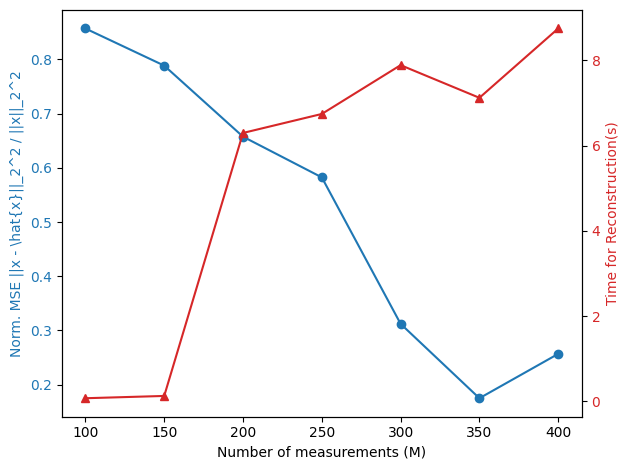

In [32]:
x = range(100,401,50)

fig, ax1 = plt.subplots()

color1 = 'tab:blue'
ax1.set_xlabel('Number of measurements (M)')
ax1.set_ylabel('Norm. MSE ||x - \hat{x}||_2^2 / ||x||_2^2', color=color1)
ax1.plot(x, nmse_means, color=color1, marker='o', label='Norm. MSE')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()

color2 = 'tab:red'
ax2.set_ylabel('Time for Reconstruction(s)', color=color2)
ax2.plot(x, comp_time_means, color=color2, marker='^', label='Time (s)')
ax2.tick_params(axis='y', labelcolor=color2)

# plt.title('Multiple Line Plots with Separate Y-Axes')
fig.tight_layout() # Ensures the right y-label is not slightly clipped
plt.show()


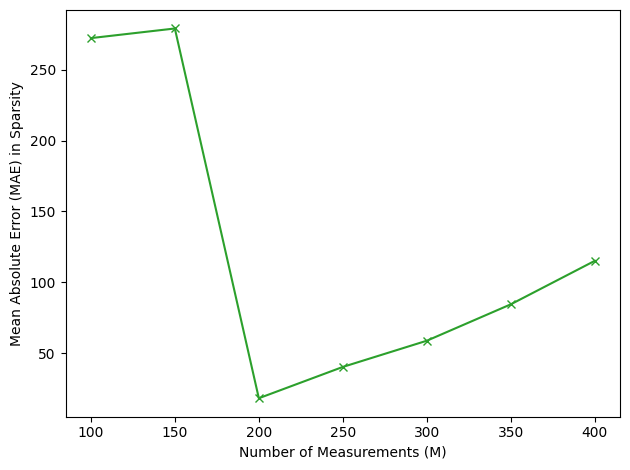

In [34]:
plt.plot(x, sparse_err_means, color='tab:green', marker='x')
plt.xlabel('Number of Measurements (M)')
plt.ylabel('Mean Absolute Error (MAE) in Sparsity')
plt.tight_layout()
plt.show()